Optimizer            | LR    | Iters  | Time(s)  | Final Loss   | Final X
----------------------------------------------------------------------------------------------------

=== OPTIMIZING: Rosenbrock Function ===
Gradient Descent     | 0.01  | 5      | 0.0003   | 1828956079967341312485638001413902142604314095617205506743032894929448779494418233266988693620210542149894144.000000 | [3.67748423e+26 4.07402679e+17]
SGD with Momentum    | 0.01  | 5      | 0.0003   | 1401167761416967218423983984702964452854863134755626084042944356607431130391939089720125133352986577811275776.000000 | [6.53696463e+26 7.40443557e+17]
Adam                 | 0.01  | 1000   | 0.0515   | 4.426262     | [-1.1025  1.222 ]
RMSprop              | 0.01  | 1000   | 0.0164   | 0.046374     | [0.826 0.695]
Adagrad              | 0.01  | 1000   | 0.0151   | 5.314871     | [-1.3019  1.7076]


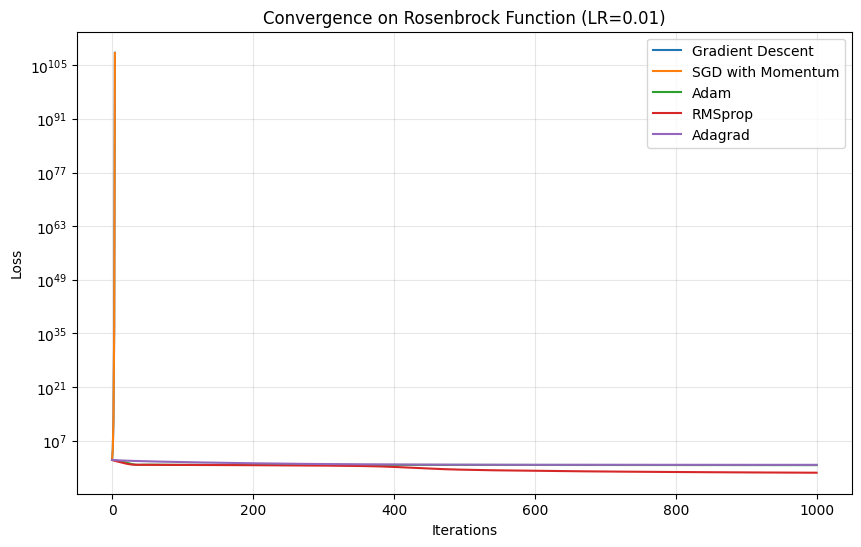

Gradient Descent     | 0.05  | 4      | 0.0001   | 22999444048518288245086018237423956563691066312131807066052686979792896.000000 | [-1.23148559e+17  3.35943477e+11]
SGD with Momentum    | 0.05  | 4      | 0.0002   | 22972625172372654948249728327709985504573987613418178197745078334652416.000000 | [-2.33914023e+17  6.38168501e+11]
Adam                 | 0.05  | 1000   | 0.0405   | 0.138053     | [0.6297 0.3953]
RMSprop              | 0.05  | 1000   | 0.0416   | 0.466871     | [0.7013 0.4329]
Adagrad              | 0.05  | 1000   | 0.0253   | 5.056197     | [-1.2475  1.5631]


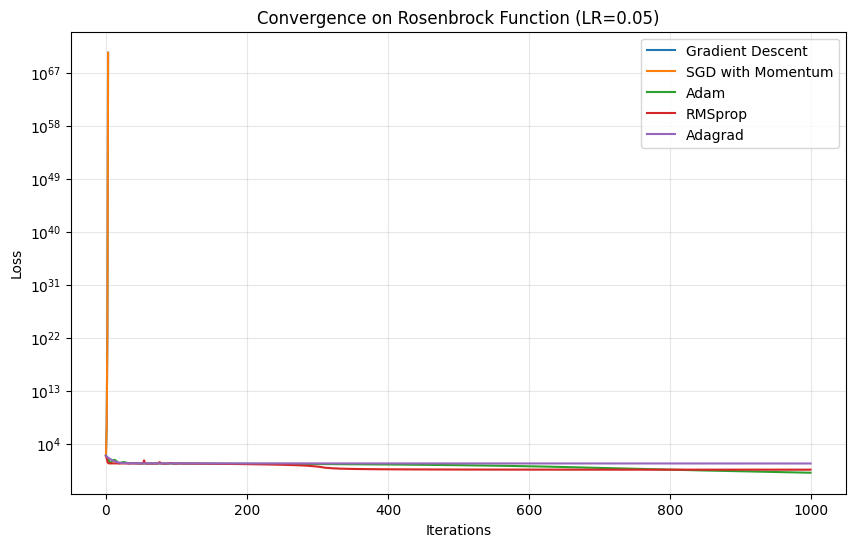

Gradient Descent     | 0.1   | 4      | 0.0007   | 39485357648251680788711530163293969435058189870181259149409247347659823301083072036864.000000 | [-7.92700294e+20  1.46463479e+14]
SGD with Momentum    | 0.1   | 4      | 0.0002   | 39479117802454804765372800624045522917748462058131842933825362295720138872274695487488.000000 | [-1.50607105e+21  2.78273281e+14]
Adam                 | 0.1   | 1000   | 0.0465   | 0.006728     | [0.9184 0.8431]
RMSprop              | 0.1   | 1000   | 0.0285   | 1.052500     | [0.2   0.115]
Adagrad              | 0.1   | 1000   | 0.0252   | 4.469571     | [-1.1129  1.2452]


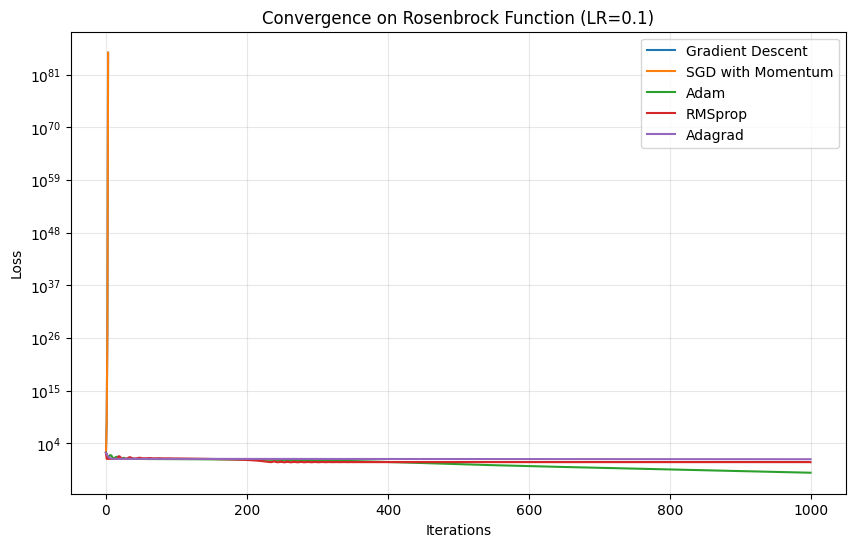


=== OPTIMIZING: Sin(1/x) ===
Gradient Descent     | 0.01  | 200    | 0.0134   | 0.912093     | [0.4854]
SGD with Momentum    | 0.01  | 200    | 0.0114   | 0.029668     | [33.7018]
Adam                 | 0.01  | 200    | 0.0183   | -1.000000    | [0.2122]
RMSprop              | 0.01  | 23     | 0.0016   | -1.000000    | [0.2122]
Adagrad              | 0.01  | 200    | 0.0136   | -0.999971    | [0.2125]


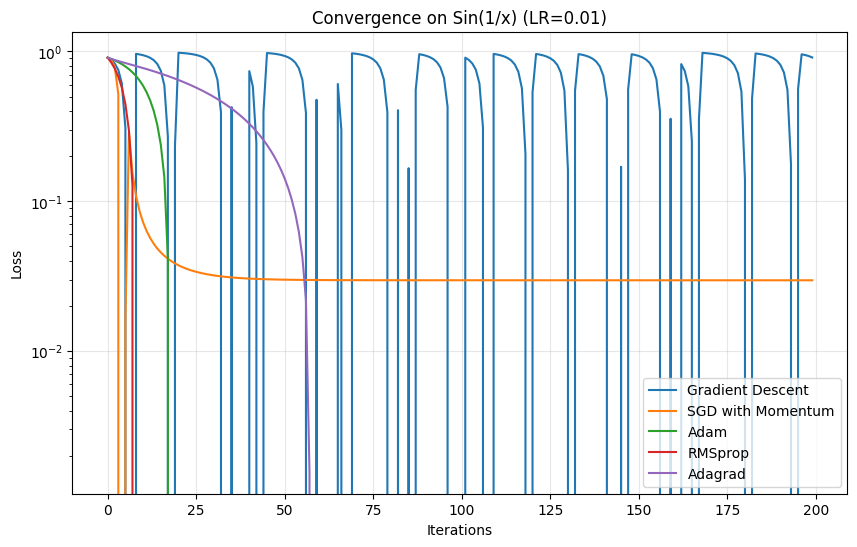

Gradient Descent     | 0.05  | 200    | 0.0212   | 0.329910     | [2.9797]
SGD with Momentum    | 0.05  | 200    | 0.0118   | 0.080233     | [12.4535]
Adam                 | 0.05  | 200    | 0.0167   | -1.000000    | [0.2122]
RMSprop              | 0.05  | 200    | 0.0165   | -0.867974    | [0.1935]
Adagrad              | 0.05  | 14     | 0.0012   | -1.000000    | [0.2122]


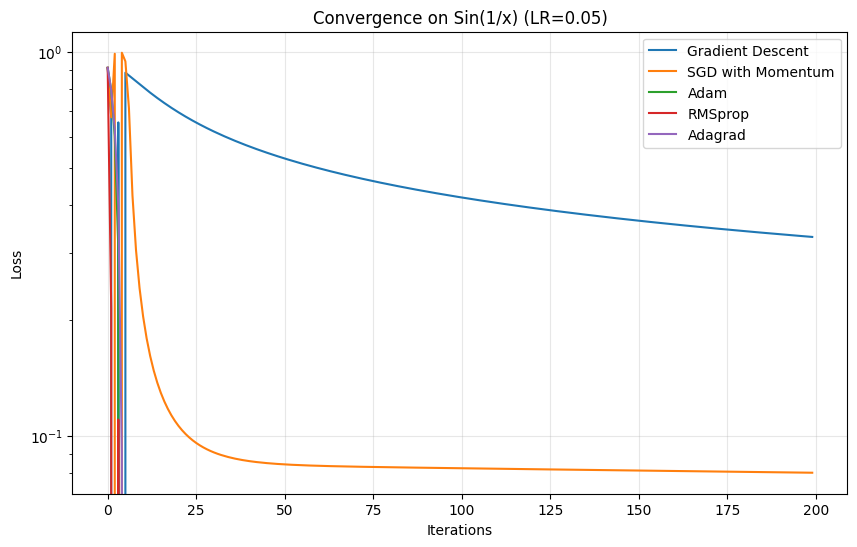

Gradient Descent     | 0.1   | 11     | 0.0014   | -1.000000    | [-0.6366]
SGD with Momentum    | 0.1   | 200    | 0.0134   | -0.177155    | [-5.5861]
Adam                 | 0.1   | 200    | 0.0148   | -1.000000    | [0.2122]
RMSprop              | 0.1   | 78     | 0.0053   | -1.000000    | [0.2122]
Adagrad              | 0.1   | 49     | 0.0033   | -1.000000    | [0.2122]


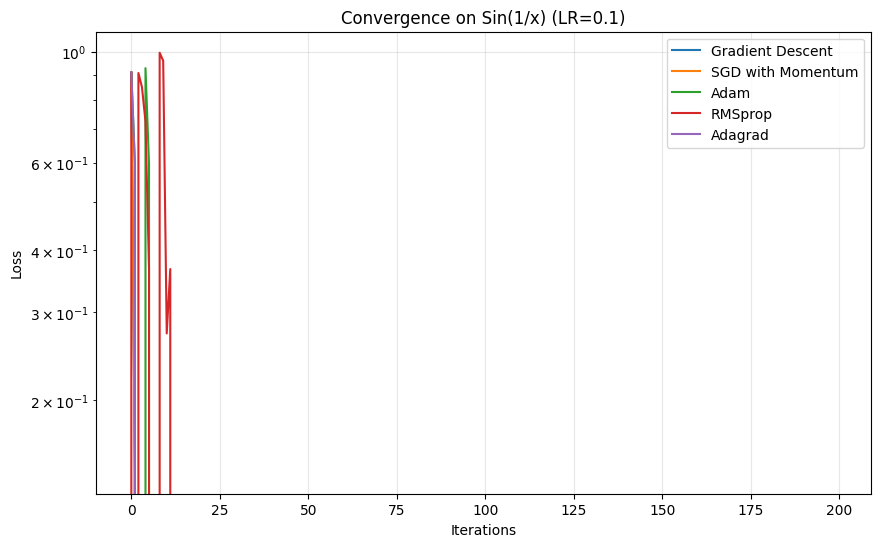

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time  # Added to satisfy "time taken"

# ==========================================
# 1. Define Objective Functions
# ==========================================

class Rosenbrock:
    def __init__(self):
        self.name = "Rosenbrock Function"

    def evaluate(self, w):
        x, y = w[0], w[1]
        try:
            val = (1 - x)**2 + 100 * (y - x**2)**2
            return val
        except OverflowError:
            return np.inf

    def gradient(self, w):
        x, y = w[0], w[1]
        # Safety check for huge numbers to prevent overflow
        if abs(x) > 1e10 or abs(y) > 1e10:
            return np.array([0.0, 0.0])

        df_dx = -2 * (1 - x) - 400 * x * (y - x**2)
        df_dy = 200 * (y - x**2)
        return np.array([df_dx, df_dy])

class SinFunction:
    def __init__(self):
        self.name = "Sin(1/x)"

    def evaluate(self, w):
        x = w[0]
        # Handle x=0 constraint
        if np.isclose(x, 0, atol=1e-8): return 0.0
        return np.sin(1 / x)

    def gradient(self, w):
        x = w[0]
        if np.isclose(x, 0, atol=1e-8): return np.array([0.0])
        grad = -np.cos(1 / x) / (x**2)
        return np.array([grad])

# ==========================================
# 2. Define Optimizers
# ==========================================

class Optimizer:
    def __init__(self, lr=0.01):
        self.lr = lr
    def step(self, weights, grad):
        raise NotImplementedError

class GradientDescent(Optimizer):
    def step(self, weights, grad):
        return weights - self.lr * grad

class Momentum(Optimizer):
    def __init__(self, lr=0.01, beta=0.9):
        super().__init__(lr)
        self.beta = beta
        self.velocity = None

    def step(self, weights, grad):
        if self.velocity is None or self.velocity.shape != weights.shape:
            self.velocity = np.zeros_like(weights)
        self.velocity = self.beta * self.velocity + self.lr * grad
        return weights - self.velocity

class RMSprop(Optimizer):
    def __init__(self, lr=0.01, beta=0.9, epsilon=1e-8):
        super().__init__(lr)
        self.beta = beta
        self.epsilon = epsilon
        self.cache = None

    def step(self, weights, grad):
        if self.cache is None or self.cache.shape != weights.shape:
            self.cache = np.zeros_like(weights)
        self.cache = self.beta * self.cache + (1 - self.beta) * grad**2
        update = (self.lr / (np.sqrt(self.cache) + self.epsilon)) * grad
        return weights - update

class Adam(Optimizer):
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None
        self.v = None
        self.t = 0

    def step(self, weights, grad):
        if self.m is None or self.m.shape != weights.shape:
            self.m = np.zeros_like(weights)
            self.v = np.zeros_like(weights)

        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * grad**2

        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)

        update = (self.lr / (np.sqrt(v_hat) + self.epsilon)) * m_hat
        return weights - update

class Adagrad(Optimizer):
    def __init__(self, lr=0.01, epsilon=1e-8):
        super().__init__(lr)
        self.epsilon = epsilon
        self.cache = None

    def step(self, weights, grad):
        if self.cache is None or self.cache.shape != weights.shape:
            self.cache = np.zeros_like(weights)
        self.cache += grad**2
        update = (self.lr / (np.sqrt(self.cache) + self.epsilon)) * grad
        return weights - update

# ==========================================
# 3. Main Execution Loop
# ==========================================

def run_experiment():
    # Setup
    functions = [
        (Rosenbrock(), [-1.0, 2.0]),
        (SinFunction(), [0.5])
    ]

    learning_rates = [0.01, 0.05, 0.1] #

    optimizer_classes = {
        "Gradient Descent": GradientDescent,
        "SGD with Momentum": Momentum,
        "Adam": Adam,
        "RMSprop": RMSprop,
        "Adagrad": Adagrad
    }

    print(f"{'Optimizer':<20} | {'LR':<5} | {'Iters':<6} | {'Time(s)':<8} | {'Final Loss':<12} | {'Final X'}")
    print("-" * 100)

    for func, start_point in functions:
        print(f"\n=== OPTIMIZING: {func.name} ===")

        for lr in learning_rates:
            plt.figure(figsize=(10, 6))
            plots_added = 0

            for opt_name, OptClass in optimizer_classes.items():
                weights = np.array(start_point, dtype=float)
                optimizer = OptClass(lr=lr)
                history = []
                diverged = False

                # Start Timer
                start_time = time.time()

                steps = 1000 if isinstance(func, Rosenbrock) else 200
                converged_step = steps

                for i in range(steps):
                    try:
                        loss = func.evaluate(weights)

                        # Divergence Check
                        if not np.isfinite(loss):
                            diverged = True
                            converged_step = i
                            break

                        history.append(loss)
                        grad = func.gradient(weights)
                        weights = optimizer.step(weights, grad)

                        # Threshold Check
                        if np.linalg.norm(grad) < 1e-4:
                            converged_step = i + 1
                            break

                    except (RuntimeWarning, OverflowError):
                        diverged = True
                        break

                # Stop Timer
                elapsed_time = time.time() - start_time

                # Print Results Table
                loss_str = "DIVERGED" if diverged else f"{history[-1]:.6f}"
                x_str = "NaN" if diverged else str(np.round(weights, 4))

                print(f"{opt_name:<20} | {lr:<5} | {converged_step:<6} | {elapsed_time:.4f}   | {loss_str:<12} | {x_str}")

                # Plot
                safe_history = [h for h in history if np.isfinite(h)]
                if len(safe_history) > 1:
                    plt.plot(safe_history, label=opt_name)
                    plots_added += 1

            if plots_added > 0:
                plt.title(f"Convergence on {func.name} (LR={lr})")
                plt.xlabel("Iterations")
                plt.ylabel("Loss")
                try:
                    plt.yscale("log")
                except:
                    plt.yscale("linear")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()

if __name__ == "__main__":
    np.seterr(all='ignore')
    run_experiment()